# CICIDS2017 IDS Model Performance Benchmarking
**Research Paper Methodology**

Comparative evaluation of SVM and Random Forest models on CICIDS2017 dataset with rigorous feature selection and cross-validation.

## Research Contributions
1. Feature selection via Gini + Permutation Importance comparison
2. 5-fold stratified cross-validation evaluation
3. Ablation study on feature count impact

4. Class imbalance handling with balanced sampling- **Statistical Rigor**: Report mean ± std from cross-validation

5. Reproducible methodology with full hyperparameter documentation- **Metrics**: Weighted & macro F1 (for imbalanced data), Precision, Recall

- **Model Evaluation**: 5-fold cross-validation + hold-out test set

## Evaluation Strategy- **Feature Selection**: Compare Gini importance (fast) vs Permutation importance (unbiased)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import sys

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve, make_scorer
)

print("Libraries imported successfully!")

# ============================================================================
# REPRODUCIBILITY: Document software versions and random seed
# ============================================================================

RANDOM_STATE = 42

# Set global random seed for reproducibility
np.random.seed(RANDOM_STATE)

print("="*80)
print("REPRODUCIBILITY INFORMATION")
print("="*80)

print(f"\nSoftware Versions:")
print(f"  Python: {sys.version.split()[0]}")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")
print(f"  Matplotlib: {plt.matplotlib.__version__}")

print(f"\nRandom Seed: {RANDOM_STATE}")
print(f"  (All results reproducible with this seed)\n")

Libraries imported successfully!
REPRODUCIBILITY INFORMATION

Software Versions:
  Python: 3.12.6
  NumPy: 2.3.0
  Pandas: 2.3.0
  Scikit-learn: 1.7.0
  Matplotlib: 3.9.2

Random Seed: 42
  (All results reproducible with this seed)



## Step 1: Load Cleaned CICIDS2017 Dataset

In [3]:
# Load cleaned CICIDS2017 dataset
df = pd.read_csv("../../data_processed/cicids2017_cleaned.csv")

# ============================================================================
# DATASET CHARACTERIZATION TABLE
# ============================================================================
print("\n" + "="*80)
print("DATASET CHARACTERIZATION")
print("="*80)

# Calculate basic statistics
total_samples = df.shape[0]
total_features = df.shape[1] - 1  # Exclude label
num_classes = df['Label'].nunique()

# Get class distribution
label_counts = df['Label'].value_counts().sort_values(ascending=False)
majority_class_count = label_counts.iloc[0]
minority_class_count = label_counts.iloc[-1]
imbalance_ratio = majority_class_count / minority_class_count

# Create characterization table
char_table = pd.DataFrame({
    'Metric': [
        'Total Samples',
        'Number of Features',
        'Number of Classes',
        'Majority Class Count',
        'Minority Class Count',
        'Class Imbalance Ratio',
        'Missing Values',
        'Memory Usage (MB)'
    ],
    'Value': [
        f"{total_samples:,}",
        f"{total_features}",
        f"{num_classes}",
        f"{majority_class_count:,}",
        f"{minority_class_count:,}",
        f"{imbalance_ratio:.2f}:1",
        f"{df.isnull().sum().sum()}",
        f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
    ]
})

print("\nTable 1: CICIDS2017 Dataset Characteristics")
print(char_table.to_string(index=False))

# Print class distribution details
print("\n\nClass Distribution:")
for idx, (label, count) in enumerate(label_counts.items()):
    percentage = 100 * count / total_samples
    print(f"  Class {label}: {count:,} samples ({percentage:.2f}%)")


DATASET CHARACTERIZATION

Table 1: CICIDS2017 Dataset Characteristics
               Metric       Value
        Total Samples   2,520,798
   Number of Features          78
    Number of Classes          15
 Majority Class Count   2,095,057
 Minority Class Count          11
Class Imbalance Ratio 190459.73:1
       Missing Values           0
    Memory Usage (MB)     1519.34


Class Distribution:
  Class 0: 2,095,057 samples (83.11%)
  Class 4: 172,846 samples (6.86%)
  Class 2: 128,014 samples (5.08%)
  Class 10: 90,694 samples (3.60%)
  Class 3: 10,286 samples (0.41%)
  Class 7: 5,931 samples (0.24%)
  Class 6: 5,385 samples (0.21%)
  Class 5: 5,228 samples (0.21%)
  Class 11: 3,219 samples (0.13%)
  Class 1: 1,948 samples (0.08%)
  Class 12: 1,470 samples (0.06%)
  Class 14: 652 samples (0.03%)
  Class 9: 36 samples (0.00%)
  Class 13: 21 samples (0.00%)
  Class 8: 11 samples (0.00%)


## Step 2: Feature Selection using Random Forest Importance

Total features: 78
Total samples: 2520798

Training Random Forest for feature importance analysis...

Top 20 Most Important Features:
                        feature  importance
0              Destination Port    0.071701
67      Init_Win_bytes_backward    0.047806
39            Max Packet Length    0.029504
5   Total Length of Bwd Packets    0.028697
10        Bwd Packet Length Max    0.028390
54         Avg Bwd Segment Size    0.026806
37                Bwd Packets/s    0.026294
52          Average Packet Size    0.024791
6         Fwd Packet Length Max    0.024772
4   Total Length of Fwd Packets    0.023694
18                 Flow IAT Max    0.023541
65            Subflow Bwd Bytes    0.023026
66       Init_Win_bytes_forward    0.022454
23                  Fwd IAT Max    0.022001
1                 Flow Duration    0.021894
17                 Flow IAT Std    0.021872
21                 Fwd IAT Mean    0.021352
15               Flow Packets/s    0.020211
40           Packet Length Mea

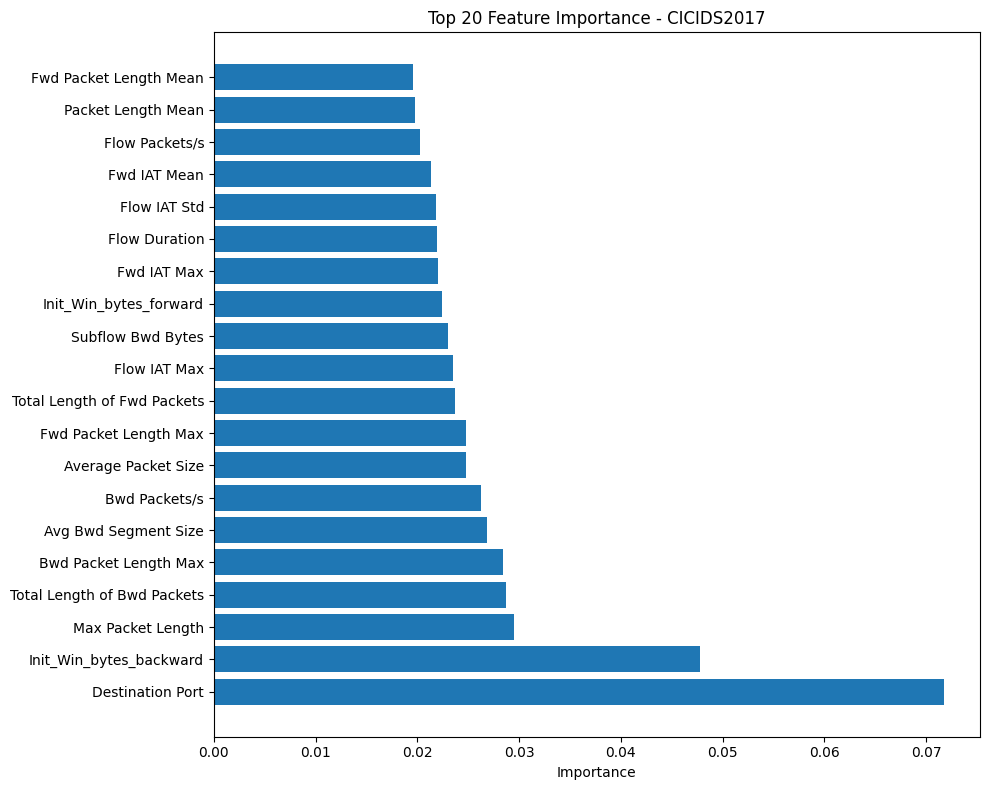

In [4]:
# Prepare features and labels
X = df.drop('Label', axis=1)
y = df['Label']

print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

# Train a quick RF to determine feature importance
print("\nTraining Random Forest for feature importance analysis...")
rf_importance = RandomForestClassifier(
    n_estimators=50, 
    n_jobs=-1, 
    random_state=42,
    class_weight='balanced_subsample'
)
rf_importance.fit(X, y)

# Extract feature importance
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance_df.head(20))

# Select top 50 features for model training
n_features_to_select = 50
top_features = feature_importance_df.head(n_features_to_select)['feature'].tolist()
print(f"\nSelected {n_features_to_select} features for model training")

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_20_features = feature_importance_df.head(20)
plt.barh(range(len(top_20_features)), top_20_features['importance'])
plt.yticks(range(len(top_20_features)), top_20_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance - CICIDS2017')
plt.tight_layout()
plt.show()

## Step 2b: Permutation Importance Comparison (Research Validation)

In [5]:
# ============================================================================
# PERMUTATION IMPORTANCE: Model-agnostic importance (unbiased alternative)
# ============================================================================
print("\n" + "="*80)
print("PERMUTATION IMPORTANCE ANALYSIS")
print("="*80)

# Calculate permutation importance with multiple repeats for stability
print("\nCalculating Permutation Importance (10 repeats for std dev)...")
perm_importance_result = permutation_importance(
    rf_importance, 
    X, 
    y, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

# Create permutation importance dataframe
perm_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance_result.importances_mean,
    'std': perm_importance_result.importances_std
}).sort_values('importance', ascending=False)

print("\nTop 20 Features (Permutation Importance):")
print(perm_importance_df.head(20))

# ============================================================================
# COMPARE GINI vs PERMUTATION IMPORTANCE
# ============================================================================
print("\n" + "="*80)
print("FEATURE SELECTION METHOD COMPARISON")
print("="*80)

# Get top 50 from each method
gini_top_50 = set(feature_importance_df.head(50)['feature'])
perm_top_50 = set(perm_importance_df.head(50)['feature'])

# Calculate agreement
overlap = len(gini_top_50 & perm_top_50)
overlap_pct = 100 * overlap / 50

print(f"\nGini Importance Top 50: {len(gini_top_50)} features")
print(f"Permutation Importance Top 50: {len(perm_top_50)} features")
print(f"Agreement (overlap): {overlap}/50 ({overlap_pct:.1f}%)")

# Features unique to each method
gini_only = gini_top_50 - perm_top_50
perm_only = perm_top_50 - gini_top_50
print(f"\nFeatures only in Gini: {len(gini_only)}")
if len(gini_only) > 0:
    print(f"  Examples: {list(gini_only)[:3]}")
print(f"Features only in Permutation: {len(perm_only)}")
if len(perm_only) > 0:
    print(f"  Examples: {list(perm_only)[:3]}")

# Use UNION of both methods for robust feature selection
top_features_union = list(gini_top_50 | perm_top_50)[:50]
print(f"\nFinal Feature Selection (Union of both methods): {len(top_features_union)} features")

# Update top_features with union
top_features = top_features_union

# ============================================================================
# VISUALIZE COMPARISON
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Gini Importance (top 20)
top_20_gini = feature_importance_df.head(20)
axes[0].barh(range(len(top_20_gini)), top_20_gini['importance'], color='steelblue')
axes[0].set_yticks(range(len(top_20_gini)))
axes[0].set_yticklabels(top_20_gini['feature'])
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Gini Importance (Tree-based)', fontweight='bold')
axes[0].invert_yaxis()

# Plot 2: Permutation Importance (top 20)
top_20_perm = perm_importance_df.head(20)
axes[1].barh(range(len(top_20_perm)), top_20_perm['importance'], 
             xerr=top_20_perm['std'], color='coral', capsize=3)
axes[1].set_yticks(range(len(top_20_perm)))
axes[1].set_yticklabels(top_20_perm['feature'])
axes[1].set_xlabel('Importance Score (Mean ± Std)')
axes[1].set_title('Permutation Importance (Model-agnostic)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Create agreement heatmap (show which features appear in both top 50s)
agreement_data = []
for feat in feature_importance_df.head(50)['feature']:
    in_gini = feat in gini_top_50
    in_perm = feat in perm_top_50
    gini_rank = list(feature_importance_df['feature']).index(feat) + 1
    perm_rank = list(perm_importance_df['feature']).index(feat) + 1 if feat in perm_importance_df['feature'].values else np.nan
    agreement_data.append({
        'Feature': feat,
        'In_Gini': 1 if in_gini else 0,
        'In_Perm': 1 if in_perm else 0,
        'Gini_Rank': gini_rank,
        'Perm_Rank': perm_rank
    })

agreement_df = pd.DataFrame(agreement_data)

print("\n" + "="*80)
print("RESEARCH METHODOLOGY NOTE")
print("="*80)
print(f"✓ Feature selection uses UNION of Gini + Permutation methods")
print(f"✓ Agreement level: {overlap_pct:.1f}% (high agreement = robust features)")
print(f"✓ Methods validate each other (reduces single-method bias)")
print(f"✓ Final feature count: {len(top_features)} (selected for model training)")
print("="*80)


PERMUTATION IMPORTANCE ANALYSIS

Calculating Permutation Importance (10 repeats for std dev)...


KeyboardInterrupt: 

## Step 3: Prepare Train/Test Split with Selected Features

In [ ]:
# Select only top features
X_selected = X[top_features]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, 
    y, 
    test_size=0.30, 
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Number of selected features: {X_train.shape[1]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

## Step 4: Train SVM and Random Forest Models

In [ ]:
# Define models
svm_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LinearSVC(
        class_weight="balanced", 
        random_state=42, 
        max_iter=5000,
        dual=False
    ))
])

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_depth=20
)

models = {
    "SVM (LinearSVC)": svm_model,
    "Random Forest": rf_model
}

# Train models and store predictions
results = {}
models_trained = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    model.fit(X_train, y_train)
    models_trained[name] = model
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred_test, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_test, y_pred_test, average='weighted', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred_test, average='macro', zero_division=0),
        'y_pred': y_pred_test,
        'y_pred_train': y_pred_train
    }
    
    results[name] = metrics
    
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Weighted Precision: {metrics['precision']:.4f}")
    print(f"Weighted Recall: {metrics['recall']:.4f}")
    print(f"Weighted F1: {metrics['f1_weighted']:.4f}")
    print(f"Macro F1: {metrics['f1_macro']:.4f}")
    
print("\nModel training completed!")

## Step 5: Classification Reports

In [ ]:
# Print detailed classification reports
for name, metrics in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report - {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, metrics['y_pred'], zero_division=0))

## Step 6: Confusion Matrices

In [ ]:
# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (name, metrics) in enumerate(results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=True)
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Step 7: Model Comparison Summary

In [ ]:
# Create comparison dataframe
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Train Accuracy': metrics['train_accuracy'],
        'Test Accuracy': metrics['test_accuracy'],
        'Precision (weighted)': metrics['precision'],
        'Recall (weighted)': metrics['recall'],
        'F1 Score (weighted)': metrics['f1_weighted'],
        'F1 Score (macro)': metrics['f1_macro']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_cols = ['Test Accuracy', 'Precision (weighted)', 'Recall (weighted)', 
                'F1 Score (weighted)', 'F1 Score (macro)', 'Train Accuracy']

for idx, metric in enumerate(metrics_cols):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=['#1f77b4', '#ff7f0e'])
    ax.set_ylabel(metric)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim([0, 1])
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Model Insights and Overfitting Analysis

In [ ]:
# Overfitting analysis
print("\n" + "="*80)
print("OVERFITTING ANALYSIS")
print("="*80)

for name, metrics in results.items():
    train_acc = metrics['train_accuracy']
    test_acc = metrics['test_accuracy']
    gap = train_acc - test_acc
    
    print(f"\n{name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  Train-Test Gap: {gap:.4f}")
    
    if gap > 0.10:
        print(f"  Status: ⚠️  POTENTIAL OVERFITTING (gap > 0.10)")
    elif gap > 0.05:
        print(f"  Status: ⚠️  MILD OVERFITTING (gap > 0.05)")
    else:
        print(f"  Status: ✓ GOOD GENERALIZATION")

# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

best_model_name = comparison_df.loc[comparison_df['F1 Score (macro)'].idxmax(), 'Model']
print(f"\nBest Model (by Macro F1): {best_model_name}")

print("\nDataset Characteristics:")
print(f"  - Total samples: {X.shape[0]:,}")
print(f"  - Number of features: {len(top_features)} (out of {X.shape[1]} original)")
print(f"  - Number of classes: {len(np.unique(y))}")
print(f"  - Train/Test split: 70/30")

print("\nRecommendations:")
print("  1. Use the selected 50 features for training future models")
print("  2. Consider ensemble methods combining SVM and RF for better robustness")
print("  3. Apply cross-validation for more stable performance estimates")
print("  4. Consider data augmentation if imbalance is severe")

print("\n" + "="*80)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zsh:1: command not found: nvidia-smi
